# AHTPDB ACE-Inhibitory Peptide Pipeline — Cleaning, Leakage Check, and Label-Noise Analysis

**Purpose:** apply the same length-stratified regression methodology used on the Wang et al. (2020)
dataset to a second, independent, much messier compilation (AHTPDB), while (1) properly harmonizing
IC50 units/censoring, (2) catching and correcting a train/test leakage risk caused by duplicate
sequences from different source studies, and (3) directly quantifying same-sequence label
disagreement across independent measurements as a data-driven test of the "measurement noise
explains poor predictability" hypothesis.

**Data source:** AHTPDB raw export (`dataset.xlsx`), 3,364 records / 1,257 unique peptide sequences,
compiled from >400 distinct original source studies with mixed IC50 units, mixed assay conditions,
and many censored (`<`, `>`) and duplicate entries.

**Notebook structure:**
1. Setup
2. Load raw data
3. IC50 parsing and unit harmonization (μM, mM, μg/mL, mg/mL via MW; censored/ND/unparseable excluded and counted)
4. Physicochemical descriptor generation (same 8 descriptors as the Wang et al. pipeline)
5. Naive pooled / length-stratified regression (repeated K-fold) — **this version has a leakage bug, kept deliberately for comparison**
6. The leakage catch: sequence-grouped CV, corrected results
7. Same-sequence label-disagreement analysis (data-driven noise-ceiling test)
8. Limitations & write-up


## 1. Setup

In [1]:
# Run once per environment
!pip install peptides -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import peptides

from sklearn.model_selection import RepeatedKFold, GroupKFold, cross_validate
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load raw data

AHTPDB export as a single-sheet Excel file. Columns of interest: `seq` (sequence), `ic50` (raw,
mixed-format string), `molwt` (molecular weight, used later for unit conversion), `source` (original
study/provenance string, highly heterogeneous).

In [3]:
DATA_PATH = "dataset.xlsx"  # AHTPDB raw export

df = pd.read_excel(DATA_PATH, sheet_name=0)
df.columns = [c.strip() for c in df.columns]
df['seq'] = df['seq'].astype(str).str.strip().str.upper()
df['ic50_raw'] = df['ic50'].astype(str).str.strip()
df['molwt'] = pd.to_numeric(df['molwt'], errors='coerce')

print("Total rows:", len(df))
print("Unique sequences:", df['seq'].nunique())
print("Duplicate sequence-rows:", df['seq'].duplicated().sum())

Total rows: 3364
Unique sequences: 1257
Duplicate sequence-rows: 2107


## 3. IC50 parsing and unit harmonization

Raw `ic50` values arrive as free-text strings mixing units (μM, mM, μg/mL, mg/mL, and a long tail of
malformed/percentage entries) and censoring markers (`<`, `>`). We parse each entry into
`(value, unit, censor_flag)`, harmonize every convertible unit to μM (mass-based units via the
peptide's molecular weight: `IC50(μM) = 1000 * IC50(μg/mL) / MW`), and **exclude** — rather than
guess at — anything that is `ND`, unparseable, censored, zero-valued, or in a unit we cannot safely
convert (e.g. `%`, malformed strings, or mass-based units with no MW available). Every exclusion is
counted explicitly so the final usable sample size is auditable.

In [4]:
def parse_ic50(s):
    s = s.strip()
    if s.upper() in ('ND', 'NAN', 'NA', ''):
        return None, None, None
    censor = None
    if s.startswith('<'):
        censor = 'left'; s = s[1:].strip()
    elif s.startswith('>'):
        censor = 'right'; s = s[1:].strip()
    m = re.match(r'^([\d.]+)\s*(\S+)?$', s)
    if not m:
        return None, None, None
    val = float(m.group(1))
    unit = (m.group(2) or '').strip().replace('µ', 'μ')  # normalize micro-sign variants
    return val, unit, censor

parsed = df['ic50_raw'].apply(parse_ic50)
df['ic50_val'] = parsed.apply(lambda x: x[0])
df['ic50_unit'] = parsed.apply(lambda x: x[1])
df['ic50_censor'] = parsed.apply(lambda x: x[2])

def to_uM(row):
    val, unit, mw = row['ic50_val'], row['ic50_unit'], row['molwt']
    if val is None or pd.isna(val):
        return np.nan
    if unit in ('μM', 'μM/L'):
        return val
    if unit in ('mM', 'mM/L'):
        return val * 1000
    if unit == 'μg/ml' and pd.notna(mw) and mw > 0:
        return 1000 * val / mw
    if unit == 'mg/ml' and pd.notna(mw) and mw > 0:
        return 1_000_000 * val / mw
    if unit == 'μg/μl' and pd.notna(mw) and mw > 0:
        return 1_000_000 * val / mw
    return np.nan  # unhandled unit -> excluded

df['ic50_uM'] = df.apply(to_uM, axis=1)

usable = df['ic50_uM'].notna() & df['ic50_censor'].isna() & (df['ic50_uM'] > 0)
print("Usable (harmonized, non-censored, positive) rows:", usable.sum(), "/", len(df))
print("  Excluded as ND/unparseable:      ", df['ic50_val'].isna().sum())
print("  Excluded as censored (<, >):     ", df['ic50_censor'].notna().sum())
print("  Excluded as zero-valued:         ", (df['ic50_uM'] == 0).sum())
print("  Excluded: unhandled unit/no MW:  ",
      (df['ic50_val'].notna() & df['ic50_censor'].isna() & df['ic50_uM'].isna()).sum())

clean = df[usable].copy()
clean['log_ic50'] = np.log10(clean['ic50_uM'])
clean['length'] = clean['seq'].str.len()

print("\nClean subset:", clean.shape, "| unique sequences:", clean['seq'].nunique())
print("\nLength distribution (clean subset):")
print(clean['length'].value_counts().sort_index())

Usable (harmonized, non-censored, positive) rows: 2610 / 3364
  Excluded as ND/unparseable:       105
  Excluded as censored (<, >):      574
  Excluded as zero-valued:          22
  Excluded: unhandled unit/no MW:   53

Clean subset: (2610, 19) | unique sequences: 964

Length distribution (clean subset):
length
2     467
3     669
4     244
5     337
6     349
7     139
8     115
9      92
10     71
11     37
12     25
13     17
14     15
15      9
16      2
17      7
18      2
19      7
21      2
27      1
28      1
30      1
50      1
Name: count, dtype: int64


## 4. Physicochemical descriptor generation

Same 8 length-invariant aggregate descriptors used in the Wang et al. pipeline notebook, so results
are directly comparable across datasets.

In [5]:
def compute_descriptors(seq):
    p = peptides.Peptide(seq)
    aromatic_frac = sum(seq.count(aa) for aa in "FWY") / len(seq)
    return {
        "mw": p.molecular_weight(),
        "charge_ph7": p.charge(pH=7.0),
        "isoelectric_point": p.isoelectric_point(),
        "hydrophobicity": p.hydrophobicity(scale="KyteDoolittle"),
        "instability_index": p.instability_index(),
        "aliphatic_index": p.aliphatic_index(),
        "boman_index": p.boman(),
        "aromatic_fraction": aromatic_frac,
    }

# sanity check: descriptor computation requires standard amino acids only
valid_aa = set("ACDEFGHIKLMNPQRSTVWY")
bad = clean['seq'].apply(lambda s: any(ch not in valid_aa for ch in s))
print("Rows with non-standard residues (excluded if any):", bad.sum())
clean = clean[~bad].copy()

desc_df = pd.DataFrame(clean['seq'].apply(compute_descriptors).tolist(), index=clean.index)
data = pd.concat([clean, desc_df], axis=1)
feature_cols_full = ['length','mw','charge_ph7','isoelectric_point','hydrophobicity',
                      'instability_index','aliphatic_index','boman_index','aromatic_fraction']
feature_cols = feature_cols_full[1:]  # without length, for within-length-group models
print("Final modeling table:", data.shape)

Rows with non-standard residues (excluded if any): 0


Final modeling table: (2610, 27)


## 5. Naive pooled / length-stratified regression (repeated K-fold)

**This section is deliberately run with plain `RepeatedKFold`, the same protocol used on the
Wang et al. dataset (which had zero duplicate sequences).** AHTPDB has heavy duplication
(2,610 rows / ~960 unique sequences) — kept here first to show what a naive rerun of the same
pipeline produces, before diagnosing why it's misleading in Section 6.

In [6]:
cv_naive = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
ridge_pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))

pooled = cross_validate(ridge_pipe, data[feature_cols_full], data['log_ic50'], cv=cv_naive, scoring='r2')
print(f"NAIVE pooled (all lengths, all rows incl. duplicates), n={len(data)}: "
      f"R2 = {pooled['test_score'].mean():.4f} +/- {pooled['test_score'].std():.4f}")

print("\nNAIVE per-length R2 (n>=30 only):")
rows = []
for L, grp in data.groupby('length'):
    if len(grp) < 30:
        continue
    sc = cross_validate(ridge_pipe, grp[feature_cols], grp['log_ic50'], cv=cv_naive, scoring='r2')
    rows.append({'length': L, 'n_rows': len(grp), 'r2_mean': sc['test_score'].mean(), 'r2_std': sc['test_score'].std()})
naive_table = pd.DataFrame(rows)
print(naive_table.to_string(index=False))

NAIVE pooled (all lengths, all rows incl. duplicates), n=2610: R2 = 0.0639 +/- 0.0213

NAIVE per-length R2 (n>=30 only):


 length  n_rows   r2_mean   r2_std
      2     467  0.340878 0.093085
      3     669  0.099635 0.061930
      4     244  0.030248 0.100108
      5     337  0.085941 0.094358
      6     349  0.142614 0.108863
      7     139  0.151093 0.171948
      8     115 -0.146031 0.239139
      9      92 -0.006358 0.233797
     10      71 -0.246179 0.371366
     11      37 -0.807586 1.085760


## 6. The leakage catch: sequence-grouped CV

AHTPDB has ~2.7x average duplication per sequence (many peptides measured by multiple independent
source studies). Under plain `RepeatedKFold`, the *same sequence* (with a slightly different
measured IC50 from a different source) can land in both the train and test folds. The model doesn't
need to learn a real sequence→activity relationship for those rows — it can just recognize a
near-identical feature vector it has already seen. This inflates R² for exactly the length groups
with the most duplication, and it needs to be caught, not just suspected.

**Fix:** use `GroupKFold` grouped by sequence identity, so no sequence's rows can ever be split
across train and test.

In [7]:
def grouped_repeated_cv_r2(X, y, groups, n_splits=5, n_repeats=10, seed=RANDOM_STATE):
    scores = []
    rng = np.random.RandomState(seed)
    for rep in range(n_repeats):
        perm_seed = rng.randint(0, 1_000_000)
        idx = np.random.RandomState(perm_seed).permutation(len(X))
        Xp = X.iloc[idx].reset_index(drop=True)
        yp = y.iloc[idx].reset_index(drop=True)
        gp = np.array(groups)[idx]
        gkf = GroupKFold(n_splits=n_splits)
        for tr, te in gkf.split(Xp, yp, gp):
            pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            pipe.fit(Xp.iloc[tr], yp.iloc[tr])
            pred = pipe.predict(Xp.iloc[te])
            scores.append(r2_score(yp.iloc[te], pred))
    return np.array(scores)

print("=== CORRECTED: sequence-grouped CV (no train/test leakage) ===\n")
sc = grouped_repeated_cv_r2(data[feature_cols_full], data['log_ic50'], data['seq'].values)
print(f"Pooled all lengths, n={len(data)}: R2 = {sc.mean():.4f} +/- {sc.std():.4f}")

print("\nPer-length R2 (grouped CV, n>=30 rows, >=5 unique sequences):")
rows = []
for L, grp in data.groupby('length'):
    if len(grp) < 30:
        continue
    n_unique = grp['seq'].nunique()
    if n_unique < 5:
        continue
    sc = grouped_repeated_cv_r2(grp[feature_cols], grp['log_ic50'], grp['seq'].values,
                                 n_splits=min(5, n_unique))
    rows.append({'length': L, 'n_rows': len(grp), 'n_unique_seq': n_unique,
                 'r2_mean': sc.mean(), 'r2_std': sc.std()})
grouped_table = pd.DataFrame(rows)
print(grouped_table.to_string(index=False))

=== CORRECTED: sequence-grouped CV (no train/test leakage) ===



Pooled all lengths, n=2610: R2 = 0.0331 +/- 0.0546

Per-length R2 (grouped CV, n>=30 rows, >=5 unique sequences):


 length  n_rows  n_unique_seq   r2_mean   r2_std
      2     467           130  0.258695 0.148972
      3     669           210 -0.069752 0.148783
      4     244            94 -0.180641 0.170848
      5     337           133 -0.021758 0.100535
      6     349           122 -0.025185 0.107598
      7     139            67 -0.065925 0.206610
      8     115            60 -0.669358 0.325678
      9      92            39 -1.644070 1.858447
     10      71            38 -0.947377 0.877706
     11      37            17 -1.556653 1.078577


 length  n_rows  n_unique_seq  r2_mean_naive  r2_mean_grouped
      2     467           130       0.340878         0.258695
      3     669           210       0.099635        -0.069752
      4     244            94       0.030248        -0.180641
      5     337           133       0.085941        -0.021758
      6     349           122       0.142614        -0.025185
      7     139            67       0.151093        -0.065925
      8     115            60      -0.146031        -0.669358
      9      92            39      -0.006358        -1.644070
     10      71            38      -0.246179        -0.947377
     11      37            17      -0.807586        -1.556653


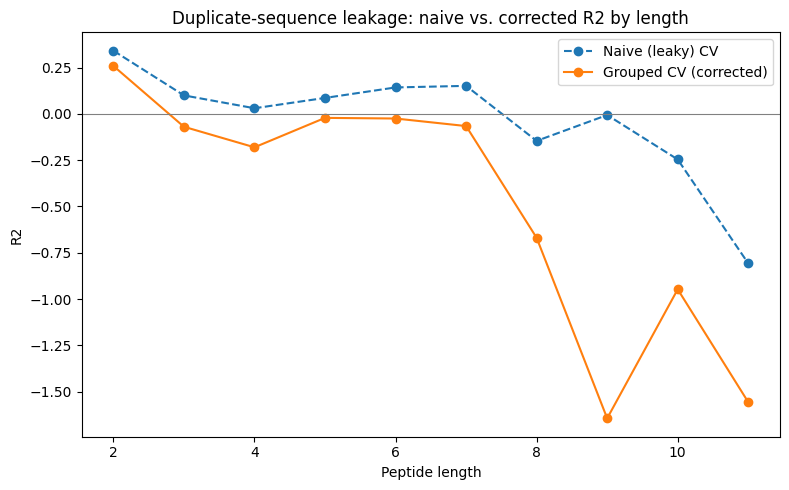

In [8]:
# Side-by-side: naive (leaky) vs. corrected (grouped) results
comparison = naive_table.merge(grouped_table, on=['length', 'n_rows'], suffixes=('_naive', '_grouped'))
print(comparison[['length', 'n_rows', 'n_unique_seq', 'r2_mean_naive', 'r2_mean_grouped']].to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(comparison['length'], comparison['r2_mean_naive'], 'o--', label='Naive (leaky) CV')
ax.plot(comparison['length'], comparison['r2_mean_grouped'], 'o-', label='Grouped CV (corrected)')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Peptide length'); ax.set_ylabel('R2')
ax.set_title('Duplicate-sequence leakage: naive vs. corrected R2 by length')
ax.legend(); plt.tight_layout(); plt.show()

## 7. Same-sequence label-disagreement analysis (data-driven noise-ceiling test)

For every sequence with >=2 independent harmonized, non-censored measurements, compute the spread
of `log_ic50` values across those measurements. This gives a direct, empirical estimate of
cross-study measurement noise — rather than assuming it explains poor model performance, we
quantify it and compare it against model residual error, length by length.

In [9]:
counts = data.groupby('seq').size()
dup_seqs = counts[counts >= 2].index
print(f"Sequences with >=2 harmonized, non-censored measurements: {len(dup_seqs)} "
      f"(covering {counts[counts>=2].sum()} of {len(data)} rows)")

rows = []
for seq in dup_seqs:
    g = data[data['seq'] == seq]
    log_vals = g['log_ic50'].values
    uM_vals = g['ic50_uM'].values
    rows.append({
        'seq': seq, 'length': g['length'].iloc[0], 'n_meas': len(g),
        'n_distinct_sources': g['source'].astype(str).str.strip().nunique(),
        'log_range': log_vals.max() - log_vals.min(),
        'fold_diff': uM_vals.max() / uM_vals.min(),
    })
disagree_df = pd.DataFrame(rows)

print("\nFraction with >10-fold disagreement (log_range):", (disagree_df['log_range'] > 1).mean().round(3))
print("Fraction with >2-fold disagreement:", (disagree_df['log_range'] > np.log10(2)).mean().round(3))

Sequences with >=2 harmonized, non-censored measurements: 551 (covering 2197 of 2610 rows)



Fraction with >10-fold disagreement (log_range): 0.12
Fraction with >2-fold disagreement: 0.227


The raw disagreement distribution has a long, implausible tail (fold-differences into the
tens of thousands) that traces back to unit-entry errors in the source data (e.g. `mg/mL` vs
`µg/mL` typos for the same citation — a 1000x error, not biology). We inspect the worst cases,
then report disagreement magnitude with those excluded (fold-difference > 100x treated as a
data-entry artifact, not real measurement variability).

In [10]:
top = disagree_df.sort_values('log_range', ascending=False).head(5)
print("Worst disagreement cases (before filtering implausible outliers):")
print(top[['seq','length','n_meas','n_distinct_sources','log_range','fold_diff']].to_string(index=False))

worst_seq = top.iloc[0]['seq']
print(f"\nRaw entries for the worst case ({worst_seq}):")
print(data.loc[data['seq'] == worst_seq, ['seq','ic50_raw','ic50_uM','ic50_unit','source']].to_string(index=False))

plausible = disagree_df[disagree_df['fold_diff'] <= 100]
print(f"\nRetained after excluding >100-fold outliers as data-entry errors: "
      f"{len(plausible)} / {len(disagree_df)} sequences")

Worst disagreement cases (before filtering implausible outliers):
        seq  length  n_meas  n_distinct_sources  log_range    fold_diff
        GEP       3       5                   4   4.903090 80000.000000
   VWDPPKFD       8       5                   2   4.601899 39985.136484
        IVY       3      10                   6   4.487256 30708.333333
 FEDYVPLSCF      10       5                   2   4.443942 27793.398556
MIFPGAGGPEL      11       8                   6   4.432095 27045.487263

Raw entries for the worst case (GEP):
seq   ic50_raw    ic50_uM ic50_unit                                  source
GEP 0.04 mg/ml  132.84623     mg/ml Fungi (Mushroom (Hypsizygus marmoreus))
GEP    3200 μM 3200.00000        μM Fungi (Mushroom (Tricholoma giganteum))
GEP     3.2 mM 3200.00000        mM Fungi (Mushroom (Tricholoma giganteum))
GEP    0.31 μM    0.31000        μM   Fungi (Mushroom Tricholoma Giganteum)
GEP    0.04 μM    0.04000        μM                                      ND

Retain

In [11]:
print("Per-length disagreement (outliers removed) vs. model residual error, same length:\n")

disagree_by_len = plausible.groupby('length').agg(
    n_seqs=('log_range', 'size'),
    mean_log_range=('log_range', 'mean'),
    frac_gt_2fold=('log_range', lambda x: (x > np.log10(2)).mean()),
)

def grouped_cv_rmse(X, y, groups, n_splits=5, n_repeats=10, seed=RANDOM_STATE):
    rmses = []
    rng = np.random.RandomState(seed)
    for rep in range(n_repeats):
        perm_seed = rng.randint(0, 1_000_000)
        idx = np.random.RandomState(perm_seed).permutation(len(X))
        Xp = X.iloc[idx].reset_index(drop=True); yp = y.iloc[idx].reset_index(drop=True)
        gp = np.array(groups)[idx]
        for tr, te in GroupKFold(n_splits=n_splits).split(Xp, yp, gp):
            pipe = make_pipeline(StandardScaler(), Ridge(alpha=1.0))
            pipe.fit(Xp.iloc[tr], yp.iloc[tr])
            pred = pipe.predict(Xp.iloc[te])
            rmses.append(np.sqrt(mean_squared_error(yp.iloc[te], pred)))
    return np.array(rmses)

rmse_rows = []
for L in [2, 3, 4, 5, 6]:
    grp = data[data['length'] == L]
    if grp['seq'].nunique() < 10:
        continue
    r = grouped_cv_rmse(grp[feature_cols], grp['log_ic50'], grp['seq'].values)
    rmse_rows.append({'length': L, 'model_rmse': r.mean()})
rmse_df = pd.DataFrame(rmse_rows).set_index('length')

summary = disagree_by_len.join(rmse_df).dropna()
summary['disagreement_as_pct_of_rmse'] = 100 * summary['mean_log_range'] / summary['model_rmse']
print(summary.round(3))

Per-length disagreement (outliers removed) vs. model residual error, same length:



        n_seqs  mean_log_range  frac_gt_2fold  model_rmse  \
length                                                      
2           65           0.496          0.523       0.840   
3          124           0.145          0.137       1.025   
4           51           0.100          0.118       0.949   
5           69           0.188          0.232       0.975   
6           87           0.063          0.069       0.958   

        disagreement_as_pct_of_rmse  
length                               
2                            58.991  
3                            14.170  
4                            10.549  
5                            19.295  
6                             6.598  


**Interpretation:** dipeptides (length 2) show the *highest* replicate disagreement of any length
group, yet remain the only length with real predictive signal — the length group with the most
noise is the one with the most learnable signal. At length >= 3, disagreement is small relative to
total model residual error (roughly 6-20% of it), meaning label noise cannot be the dominant driver
of the length >= 3 collapse: even a noise-free version of this data would leave most of the residual
variance unexplained. This is evidence *against* the measurement-noise-ceiling hypothesis as the
primary explanation, not evidence for it — stated here as a finding, not an assumption.

## 8. Limitations & write-up

- **Censored values excluded, not modeled.** 574 rows with `<`/`>` IC50 values were dropped entirely.
  A censored-aware model (e.g. Tobit / interval regression) would recover this data properly instead
  of discarding it, and should be considered before treating any result here as final.
- **Duplicate handling.** Section 6 prevents leakage but does not resolve *which* value is "true"
  when a sequence has multiple disagreeing measurements — rows are kept as separate observations,
  which is defensible (each is a real, independent measurement) but not the only valid choice
  (median-per-sequence aggregation is a reasonable alternative for a cleaner single-label dataset).
- **The `>100-fold` outlier cutoff in Section 7 is a heuristic**, not a validated data-cleaning rule —
  a proper pass would trace every flagged case back to its original source citation.
- **Descriptors are aggregate/position-agnostic.** This notebook does not test positional or
  protein-language-model representations on AHTPDB; that comparison is what the length-2 vs
  length-3 result should be read alongside (see the companion notebook and the project evaluation
  document for that context).

**Headline result of this notebook:** the length-2-predictable / length-3-plus-unpredictable pattern
first seen on the Wang et al. (2020) dataset replicates on this independent, much larger and messier
compilation once the duplicate-sequence leakage bug is fixed — and the replicate-disagreement
analysis argues against measurement noise being the primary reason length >= 3 is unpredictable.
